In [5]:
!pip install statsbombpy mplsoccer

In [1]:
from statsbombpy import sb
import pandas as pd
import numpy as np

In [9]:
# pull all shots from the whole competition
all_events = sb.competition_events(
    country="Europe",
    division="UEFA Women's Euro",
    season="2025",
    gender="female"
)
shots = all_events[all_events['type'] == 'Shot'].copy()
shots.shape

/opt/anaconda3/lib/python3.12/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/st

(913, 113)

In [11]:
# target and position features
shots['goal'] = (shots['shot_outcome'] == 'Goal').astype(int)
shots['x'] = shots['location'].apply(lambda loc: loc[0])
shots['y'] = shots['location'].apply(lambda loc: loc[1])

In [13]:
# distance and angle to goal
shots['distance'] = np.sqrt((120 - shots['x'])**2 + (40 - shots['y'])**2)

def shot_angle(x, y):
    g1 = np.array([120, 36])
    g2 = np.array([120, 44])
    p = np.array([x, y])
    v1 = g1 - p
    v2 = g2 - p
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

shots['angle'] = shots.apply(lambda row: shot_angle(row['x'], row['y']), axis=1)

In [15]:
# train the xG model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = shots[['distance', 'angle']]
y = shots['goal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

# xG for every shot
shots['xg'] = model.predict_proba(shots[['distance', 'angle']])[:, 1]

In [17]:
# player-level goals vs xG
player_summary = shots.groupby('player').agg(
    shots=('goal', 'count'),
    goals=('goal', 'sum'),
    xg=('xg', 'sum')
).reset_index()
player_summary['goals_minus_xg'] = player_summary['goals'] - player_summary['xg']
player_summary = player_summary[player_summary['shots'] >= 5]

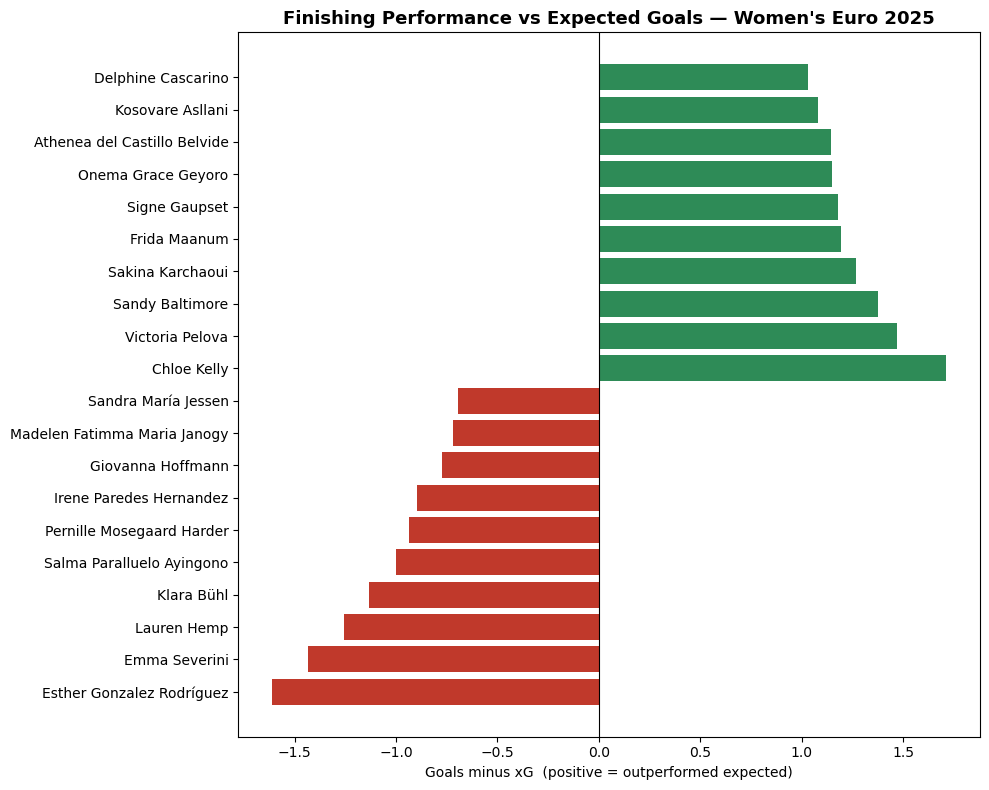

In [19]:
# the chart
import matplotlib.pyplot as plt

top = player_summary.sort_values('goals_minus_xg', ascending=False).head(10)
bottom = player_summary.sort_values('goals_minus_xg').head(10)
combined = pd.concat([bottom, top])
colors = ['#2E8B57' if v > 0 else '#C0392B' for v in combined['goals_minus_xg']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(combined['player'], combined['goals_minus_xg'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Goals minus xG  (positive = outperformed expected)')
ax.set_title("Finishing Performance vs Expected Goals — Women's Euro 2025", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('finishing_vs_xg.png', dpi=150, bbox_inches='tight')
plt.show()